# University of Stirling
# ITNPBD2 — Representing and Manipulating Data
# Assignment Spring 2026

**Student Number:** 3539856

---

# Section 1: Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import json
import os
import warnings

warnings.filterwarnings('ignore')

print("Core libraries ready.")

Core libraries ready.


# Section 2: Business Understanding

*(Narrative to be written — draft will be reviewed before adding)*

# Section 3: Data Understanding and Preparation

In [3]:
# We have 3 CSV files and 2 NDJSON files to load.
# CSV files load directly with pandas. NDJSON files store one JSON record per line,
# so we read them line by line and build a DataFrame from the collected records.

products_csv = pd.read_csv("JCPenneyFiles/products.csv")
reviews_csv  = pd.read_csv("JCPenneyFiles/reviews.csv")
users_csv    = pd.read_csv("JCPenneyFiles/users.csv")

def load_ndjson(filepath):
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return pd.DataFrame(records)

products_json  = load_ndjson("JCPenneyFiles/jcpenney_products.json")
reviewers_json = load_ndjson("JCPenneyFiles/jcpenney_reviewers.json")

# Confirming every file loaded correctly — we print row counts and column names
# so we can spot immediately if a file is missing or came in with unexpected structure.
print(f"products_csv   : {products_csv.shape[0]:,} rows, columns: {list(products_csv.columns)}")
print(f"reviews_csv    : {reviews_csv.shape[0]:,} rows, columns: {list(reviews_csv.columns)}")
print(f"users_csv      : {users_csv.shape[0]:,} rows, columns: {list(users_csv.columns)}")
print(f"products_json  : {products_json.shape[0]:,} rows, columns: {list(products_json.columns)}")
print(f"reviewers_json : {reviewers_json.shape[0]:,} rows, columns: {list(reviewers_json.columns)}")

products_csv   : 7,982 rows, columns: ['Uniq_id', 'SKU', 'Name', 'Description', 'Price', 'Av_Score']
reviews_csv    : 39,063 rows, columns: ['Uniq_id', 'Username', 'Score', 'Review']
users_csv      : 5,000 rows, columns: ['Username', 'DOB', 'State']
products_json  : 7,982 rows, columns: ['uniq_id', 'sku', 'name_title', 'description', 'list_price', 'sale_price', 'category', 'category_tree', 'average_product_rating', 'product_url', 'product_image_urls', 'brand', 'total_number_reviews', 'Reviews', 'Bought With']
reviewers_json : 5,000 rows, columns: ['Username', 'DOB', 'State', 'Reviewed']


In [4]:
# We want a quick snapshot of each dataset's column types and a sample row
# so we can spot type issues (e.g. prices stored as strings) before cleaning.

print("--- products_json ---")
print(products_json.dtypes)
print(products_json[["uniq_id", "list_price", "sale_price", "average_product_rating", "brand", "category_tree"]].head(2))

print("\n--- reviews_csv ---")
print(reviews_csv.dtypes)
print(reviews_csv.head(2))

print("\n--- users_csv ---")
print(users_csv.dtypes)
print(users_csv.head(2))

--- products_json ---
uniq_id                    object
sku                        object
name_title                 object
description                object
list_price                 object
sale_price                 object
category                   object
category_tree              object
average_product_rating    float64
product_url                object
product_image_urls         object
brand                      object
total_number_reviews        int64
Reviews                    object
Bought With                object
dtype: object
                            uniq_id list_price sale_price  \
0  b6c0b6bea69c722939585baeac73c13d      41.09      24.16   
1  93e5272c51d8cce02597e3ce67b7ad0a      41.09      24.16   

   average_product_rating          brand                 category_tree  
0                   2.625  Alfred Dunner  jcpenney|women|alfred dunner  
1                   3.000  Alfred Dunner  jcpenney|women|alfred dunner  

--- reviews_csv ---
Uniq_id     object
Username   

## 3.1 Data Quality Audit

In [5]:
# Before cleaning anything, we need to understand what problems exist in each dataset.
# We check for missing values and duplicate rows so we know exactly what needs fixing.

print("Missing Values")
print("  products_json :", products_json.isnull().sum().sum())
print("  reviews_csv   :", reviews_csv.isnull().sum().sum())
print("  users_csv     :", users_csv.isnull().sum().sum())

print("\nDuplicate Rows")
print("  products_json :", products_json.duplicated(subset=["uniq_id"]).sum())
print("  reviews_csv   :", reviews_csv.duplicated().sum())
print("  users_csv     :", users_csv.duplicated().sum())

Missing Values
  products_json : 0
  reviews_csv   : 0
  users_csv     : 0

Duplicate Rows
  products_json : 0
  reviews_csv   : 0
  users_csv     : 0


## 3.2 Data Cleaning

In [6]:
# Clean data types and extract categories.
# Convert prices to numbers, calculate ages, and get category from category_tree.

# --- Products ---
products = products_json.copy()

products["list_price"] = pd.to_numeric(products["list_price"], errors="coerce")
products["sale_price"] = pd.to_numeric(products["sale_price"], errors="coerce")
products["discount_pct"] = ((products["list_price"] - products["sale_price"]) / products["list_price"] * 100).round(1)

# Extract category from category_tree - take second level
products["category"] = products["category_tree"].str.split("|").str[1].str.strip().str.title()

# --- Users ---
users = users_csv.copy()
users["DOB"] = pd.to_datetime(users["DOB"], format="%d.%m.%Y", errors="coerce")
users["age"] = ((pd.Timestamp("today") - users["DOB"]).dt.days / 365.25).round(0)

# --- Reviews ---
reviews = reviews_csv.copy()
reviews.columns = ["product_id", "username", "score", "review_text"]

print("Data Cleaning Complete")
print(f"  Products : {len(products):,}")
print(f"  Users    : {len(users):,}")
print(f"  Reviews  : {len(reviews):,}")
print(f"\nProducts with prices : {products['list_price'].notna().sum():,} / {len(products):,}")
print(f"Unique categories    : {products['category'].nunique()}")

Data Cleaning Complete
  Products : 7,982
  Users    : 5,000
  Reviews  : 39,063

Products with prices : 5,816 / 7,982
Unique categories    : 966


## 3.3 Merging the Datasets

In [7]:
# We create a master dataset by joining reviews with product and user information.
# This gives us one row per review with all the context we need for analysis.

df = reviews.merge(
    products[["uniq_id", "name_title", "brand", "category", "list_price", "sale_price", "discount_pct"]],
    left_on="product_id",
    right_on="uniq_id",
    how="left"
)

df = df.merge(
    users[["Username", "State", "age"]],
    left_on="username",
    right_on="Username",
    how="left"
)

df = df.drop(columns=["uniq_id", "Username"])

print("Master Dataset Created")
print(f"  Total reviews : {len(df):,}")
print(f"  Columns       : {len(df.columns)}")

Master Dataset Created
  Total reviews : 39,080
  Columns       : 12


# Section 4: Exploratory Data Analysis

In [8]:
# We need visualization libraries for charts — importing them here, not at the top,
# because they are only needed from this section onwards.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Visualization libraries ready")

Visualization libraries ready


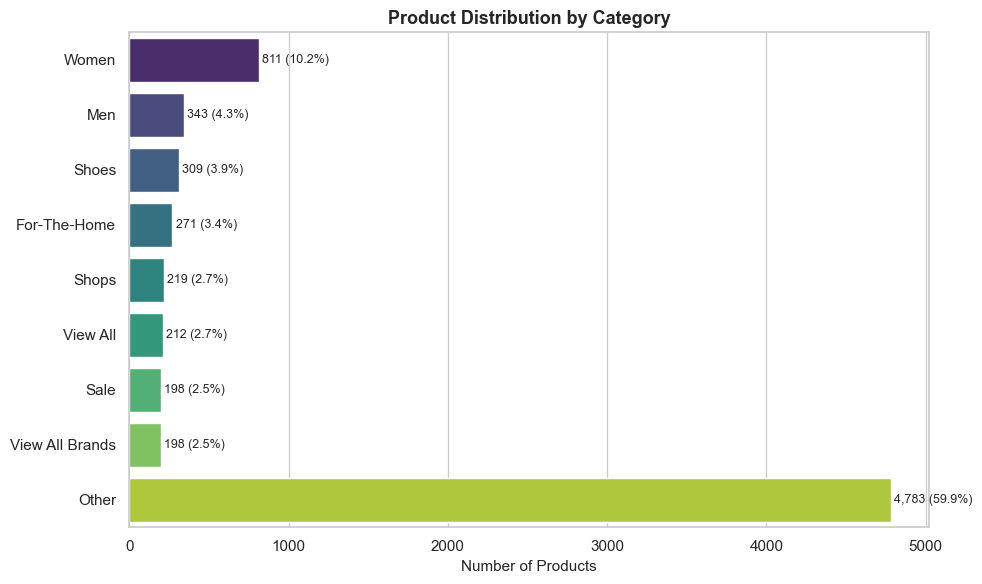

Category Distribution
  Women                : 811 (10.2%)
  Men                  : 343 (4.3%)
  Shoes                : 309 (3.9%)
  For-The-Home         : 271 (3.4%)
  Shops                : 219 (2.7%)
  View All             : 212 (2.7%)
  Sale                 : 198 (2.5%)
  View All Brands      : 198 (2.5%)
  Other                : 4,783 (59.9%)


In [9]:
# Show the main product categories and their distribution.
# Top 8 categories displayed, rest grouped as "Other".

cat_counts = products["category"].value_counts()
top_8 = cat_counts.head(8)
other_count = cat_counts[8:].sum()

plot_data = pd.concat([top_8, pd.Series({"Other": other_count})])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=plot_data.values, y=plot_data.index, palette="viridis", ax=ax)
ax.set_xlabel("Number of Products", fontsize=11)
ax.set_ylabel("")
ax.set_title("Product Distribution by Category", fontsize=13, fontweight="bold")

for i, (cat, count) in enumerate(plot_data.items()):
    pct = count / len(products) * 100
    ax.text(count + 20, i, f"{count:,} ({pct:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Category Distribution")
for cat, count in plot_data.items():
    pct = count / len(products) * 100
    print(f"  {cat:20s} : {count:,} ({pct:.1f}%)")

Price range: $-65.27 - $17122.17
95th percentile: $463.83
Products above 95th percentile: 291


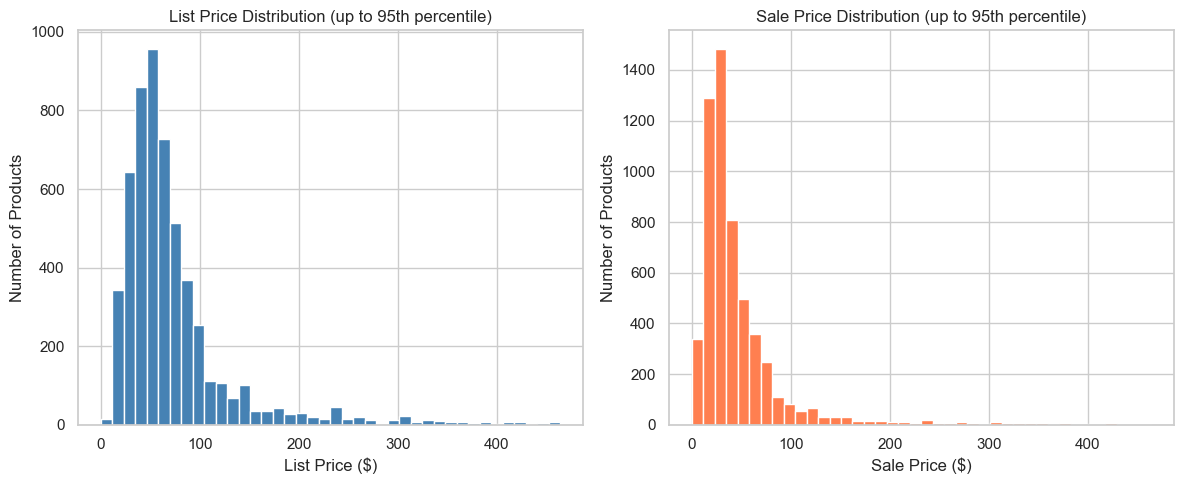


Price Summary
  Median list price  : $58.01
  Median sale price  : $32.62
  Average discount   : 42.4%


In [10]:
# Analyze pricing structure and check for outliers.
# Show distribution up to 95th percentile for clarity.

products_with_price = products[products["list_price"].notna()]

price_95th = products_with_price["list_price"].quantile(0.95)
print(f"Price range: ${products_with_price['list_price'].min():.2f} - ${products_with_price['list_price'].max():.2f}")
print(f"95th percentile: ${price_95th:.2f}")
print(f"Products above 95th percentile: {(products_with_price['list_price'] > price_95th).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(products_with_price["list_price"], bins=40, color="steelblue", edgecolor="white", range=(0, price_95th))
axes[0].set_xlabel("List Price ($)")
axes[0].set_ylabel("Number of Products")
axes[0].set_title("List Price Distribution (up to 95th percentile)")

axes[1].hist(products_with_price["sale_price"], bins=40, color="coral", edgecolor="white", range=(0, price_95th))
axes[1].set_xlabel("Sale Price ($)")
axes[1].set_ylabel("Number of Products")
axes[1].set_title("Sale Price Distribution (up to 95th percentile)")

plt.tight_layout()
plt.show()

print("\nPrice Summary")
print(f"  Median list price  : ${products_with_price['list_price'].median():.2f}")
print(f"  Median sale price  : ${products_with_price['sale_price'].median():.2f}")
print(f"  Average discount   : {products_with_price['discount_pct'].mean():.1f}%")

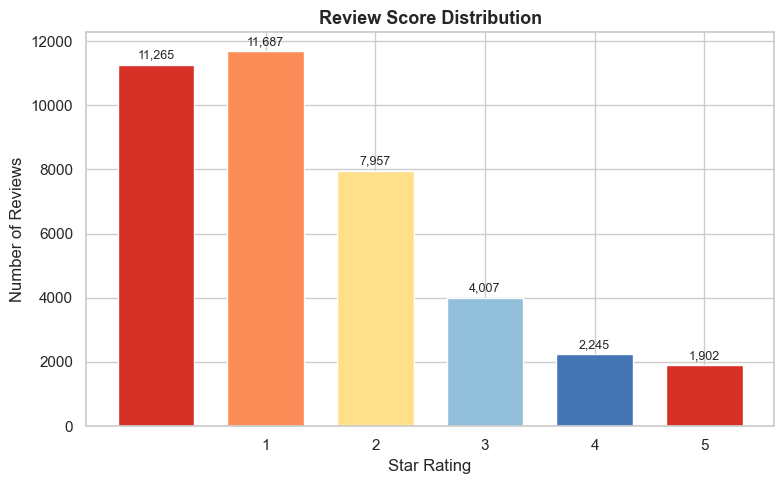

Review Score Summary
  Total reviews        : 39,063
  Positive (4-5 stars) : 10.6%
  Average score        : 1.49


In [11]:
# We want to see how customers rate products - are most reviews positive or negative?
# This tells us overall customer satisfaction levels.

score_counts = reviews["score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(score_counts.index, score_counts.values, color=["#d73027", "#fc8d59", "#fee08b", "#91bfdb", "#4575b4"], edgecolor="white", width=0.7)
ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Reviews")
ax.set_title("Review Score Distribution", fontsize=13, fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])

for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

positive_pct = (reviews["score"] >= 4).sum() / len(reviews) * 100
print("Review Score Summary")
print(f"  Total reviews        : {len(reviews):,}")
print(f"  Positive (4-5 stars) : {positive_pct:.1f}%")
print(f"  Average score        : {reviews['score'].mean():.2f}")

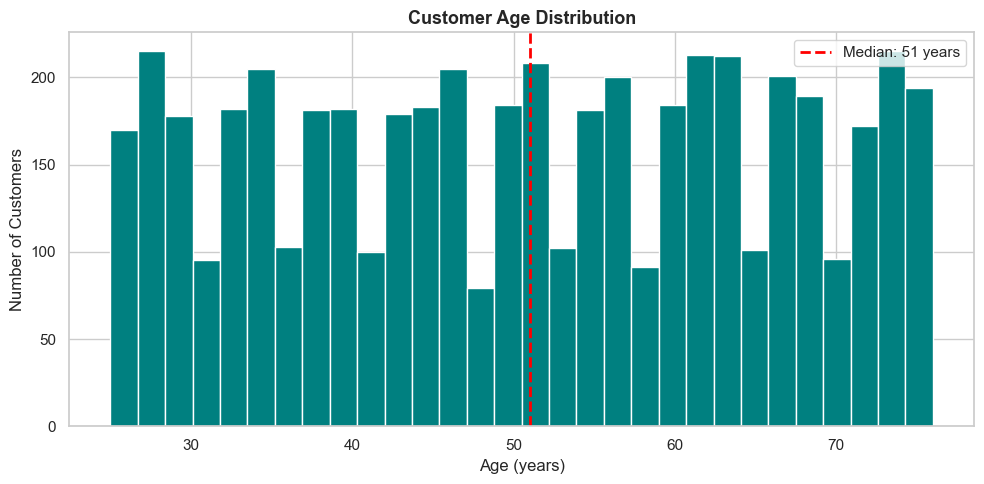

Customer Age Summary
  Median age : 51 years
  Age range  : 25 - 76 years


In [12]:
# We want to understand the age distribution of customers.
# This helps identify the primary customer demographic.

users_with_age = users[users["age"].notna()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(users_with_age["age"], bins=30, color="teal", edgecolor="white")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Age Distribution", fontsize=13, fontweight="bold")
ax.axvline(users_with_age["age"].median(), color="red", linestyle="--", linewidth=2, label=f"Median: {users_with_age['age'].median():.0f} years")
ax.legend()

plt.tight_layout()
plt.show()

print("Customer Age Summary")
print(f"  Median age : {users_with_age['age'].median():.0f} years")
print(f"  Age range  : {users_with_age['age'].min():.0f} - {users_with_age['age'].max():.0f} years")

In [20]:
# Geographic distribution - US map showing customer concentration by state.

import plotly.graph_objects as go

# Map state names to abbreviations
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

state_data = users["State"].value_counts().reset_index()
state_data.columns = ["State", "Customers"]
state_data["Code"] = state_data["State"].map(state_abbrev)

# Create choropleth map
fig = go.Figure(data=go.Choropleth(
    locations=state_data["Code"],
    z=state_data["Customers"],
    locationmode='USA-states',
    colorscale='Reds',
    colorbar_title="Customers",
    text=state_data["State"],
    hovertemplate='<b>%{text}</b><br>Customers: %{z}<extra></extra>'
))

fig.update_layout(
    title_text='Customer Distribution Across US States',
    geo_scope='usa',
    width=1000,
    height=600
)

fig.show()

total_states = users['State'].nunique()
print("Geographic Distribution Summary")
print(f"  Total customers          : {len(users):,}")
print(f"  States represented       : {total_states}")
print(f"  Average per state        : {len(users) / total_states:.1f}")
print(f"\nTop 5 states:")
for _, row in state_data.head(5).iterrows():
    pct = row['Customers'] / len(users) * 100
    print(f"  {row['State']:25s} : {row['Customers']:,} ({pct:.1f}%)")
print(f"\nObservation: Very even distribution suggests synthetic/balanced dataset")
print(f"\nNote: To save map for PDF, right-click the map and select 'Download plot as png'")

Geographic Distribution Summary
  Total customers          : 5,000
  States represented       : 57
  Average per state        : 87.7

Top 5 states:
  Massachusetts             : 107 (2.1%)
  Delaware                  : 106 (2.1%)
  Vermont                   : 103 (2.1%)
  Northern Mariana Islands  : 102 (2.0%)
  New Jersey                : 101 (2.0%)

Observation: Very even distribution suggests synthetic/balanced dataset

Note: To save map for PDF, right-click the map and select 'Download plot as png'


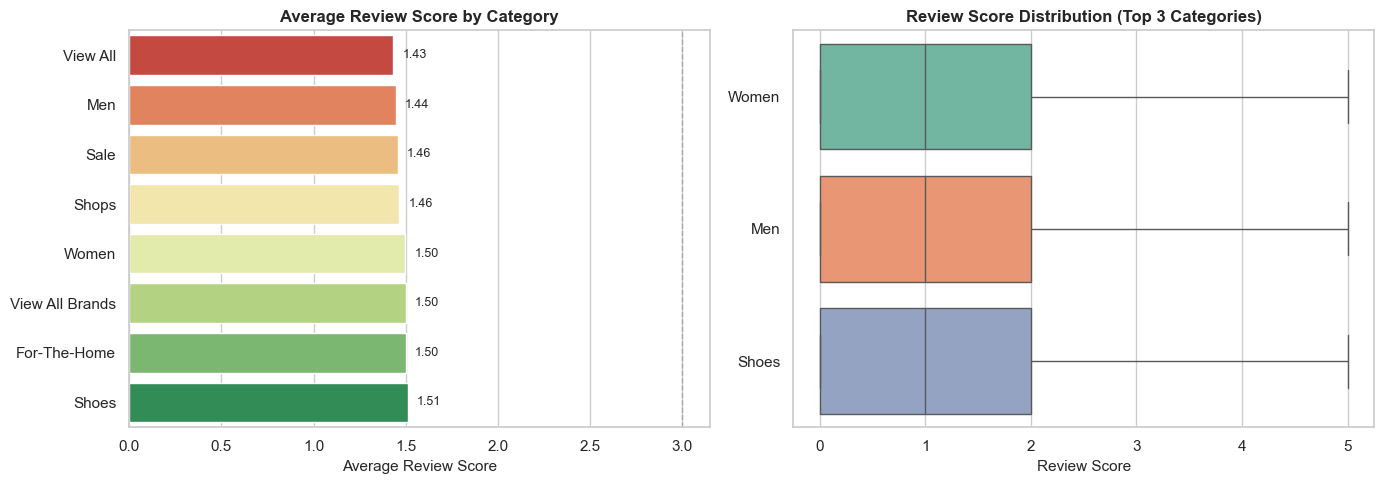

Review Score Analysis by Category
  Overall average score : 1.49

Average scores by category:
  View All             : 1.43 (1,041 reviews)
  Men                  : 1.44 (1,501 reviews)
  Sale                 : 1.46 (938 reviews)
  Shops                : 1.46 (1,050 reviews)
  Women                : 1.50 (4,147 reviews)
  View All Brands      : 1.50 (1,121 reviews)
  For-The-Home         : 1.50 (1,382 reviews)
  Shoes                : 1.51 (1,624 reviews)


In [14]:
# Analyze review scores by product category to identify problem areas.
# We calculate average scores and show distribution for top categories.

# Get top 8 categories by product count
top_categories = products["category"].value_counts().head(8).index

# Filter master dataset to only top categories
df_top = df[df["category"].isin(top_categories)].copy()

# Calculate average score by category
avg_scores = df_top.groupby("category")["score"].mean().sort_values()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average review score by category
sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="RdYlGn", ax=axes[0])
axes[0].set_xlabel("Average Review Score", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_title("Average Review Score by Category", fontsize=12, fontweight="bold")
axes[0].axvline(x=3.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for i, (cat, score) in enumerate(avg_scores.items()):
    axes[0].text(score + 0.05, i, f"{score:.2f}", va="center", fontsize=9)

# Chart 2: Review score distribution for top 3 categories
top_3_cats = products["category"].value_counts().head(3).index
df_top3 = df[df["category"].isin(top_3_cats)]

sns.boxplot(data=df_top3, y="category", x="score", palette="Set2", ax=axes[1])
axes[1].set_xlabel("Review Score", fontsize=11)
axes[1].set_ylabel("")
axes[1].set_title("Review Score Distribution (Top 3 Categories)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("Review Score Analysis by Category")
print(f"  Overall average score : {df['score'].mean():.2f}")
print(f"\nAverage scores by category:")
for cat, score in avg_scores.items():
    count = df_top[df_top["category"] == cat].shape[0]
    print(f"  {cat:20s} : {score:.2f} ({count:,} reviews)")

In [ ]:
# Brand performance analysis - identify top and bottom performing brands.
# We look at brands with sufficient reviews to make meaningful comparisons.

# Filter brands with at least 50 reviews for statistical significance
brand_stats = df.groupby("brand").agg({
    "score": ["mean", "count"],
    "product_id": "nunique"
}).reset_index()

brand_stats.columns = ["brand", "avg_score", "review_count", "product_count"]
brand_stats = brand_stats[brand_stats["review_count"] >= 50].sort_values("avg_score")

# Get top 5 and bottom 5 brands
bottom_5 = brand_stats.head(5)
top_5 = brand_stats.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Bottom 5 brands by average score
sns.barplot(data=bottom_5, y="brand", x="avg_score", palette="Reds_r", ax=axes[0])
axes[0].set_xlabel("Average Review Score", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_title("Bottom 5 Brands by Review Score", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 5)

for i, row in enumerate(bottom_5.itertuples()):
    axes[0].text(row.avg_score + 0.1, i, f"{row.avg_score:.2f}", va="center", fontsize=9)

# Chart 2: Top 5 brands by average score
sns.barplot(data=top_5, y="brand", x="avg_score", palette="Greens", ax=axes[1])
axes[1].set_xlabel("Average Review Score", fontsize=11)
axes[1].set_ylabel("")
axes[1].set_title("Top 5 Brands by Review Score", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 5)

for i, row in enumerate(top_5.itertuples()):
    axes[1].text(row.avg_score + 0.1, i, f"{row.avg_score:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Brand Performance Summary")
print(f"  Brands analyzed (50+ reviews) : {len(brand_stats)}")
print(f"\nBottom 5 brands:")
for _, row in bottom_5.iterrows():
    print(f"  {row['brand']:30s} : {row['avg_score']:.2f} ({int(row['review_count'])} reviews)")
print(f"\nTop 5 brands:")
for _, row in top_5.iterrows():
    print(f"  {row['brand']:30s} : {row['avg_score']:.2f} ({int(row['review_count'])} reviews)")

In [ ]:
# Discount effectiveness - does higher discount lead to better reviews?
# We analyze the relationship between discount percentage and review scores.

df_discount = df[df["discount_pct"].notna()].copy()

# Create discount bins
df_discount["discount_range"] = pd.cut(
    df_discount["discount_pct"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
)

discount_scores = df_discount.groupby("discount_range", observed=True)["score"].agg(["mean", "count"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average score by discount range
sns.barplot(data=discount_scores, x="discount_range", y="mean", palette="coolwarm", ax=axes[0])
axes[0].set_xlabel("Discount Range", fontsize=11)
axes[0].set_ylabel("Average Review Score", fontsize=11)
axes[0].set_title("Review Score by Discount Level", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 5)

for i, row in enumerate(discount_scores.itertuples()):
    axes[0].text(i, row.mean + 0.1, f"{row.mean:.2f}", ha="center", fontsize=9)

# Chart 2: Review count by discount range
sns.barplot(data=discount_scores, x="discount_range", y="count", palette="viridis", ax=axes[1])
axes[1].set_xlabel("Discount Range", fontsize=11)
axes[1].set_ylabel("Number of Reviews", fontsize=11)
axes[1].set_title("Review Volume by Discount Level", fontsize=12, fontweight="bold")

for i, row in enumerate(discount_scores.itertuples()):
    axes[1].text(i, row.count + 50, f"{int(row.count):,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Discount Effectiveness Analysis")
print(f"  Reviews with discount data : {len(df_discount):,}")
print(f"\nAverage score by discount range:")
for _, row in discount_scores.iterrows():
    print(f"  {row['discount_range']:10s} : {row['mean']:.2f} ({int(row['count']):,} reviews)")